# 1. Ecosystem Transition - Data Prep

If script cannot find data, open in an instance (home) instead of in the persistant storage

## Import packages & Data

In [17]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geopandas as gpd
import numpy as np

In [33]:
#CHANGE ALL FILE NAMES TO THE DESIRED STATE

state_abbr = "WY" # Available states: CO, KS, NE, MT, ND, SD, WY
Trans_yr_path = "data/iplant/home/shared/earthlab/NC_eco_transformations/Transformations/Transformed_areas/trans_nc_USA/trans_WY.tif"
Biomass_path = "data/iplant/home/shared/earthlab/NC_eco_transformations/BM_data/Total_BM_stacked/Total_BM_stacked.tif"
NC_RISCC_shp_path = "data/iplant/home/shared/earthlab/NC_eco_transformations/NC_CASC_region.shp"
output_tif_trans = "WY_trans.tif"
output_tif_bm = "biomass_clip_WY.tif"
output_tif_resampled = "bm_clip_resampled_bilinear_multiBand_WY.tif"

## Visualize Data

In [34]:
with rasterio.open(Trans_yr_path) as src:
    Trans_yr = src.read(1) # read first band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs
    nodata = src.nodata

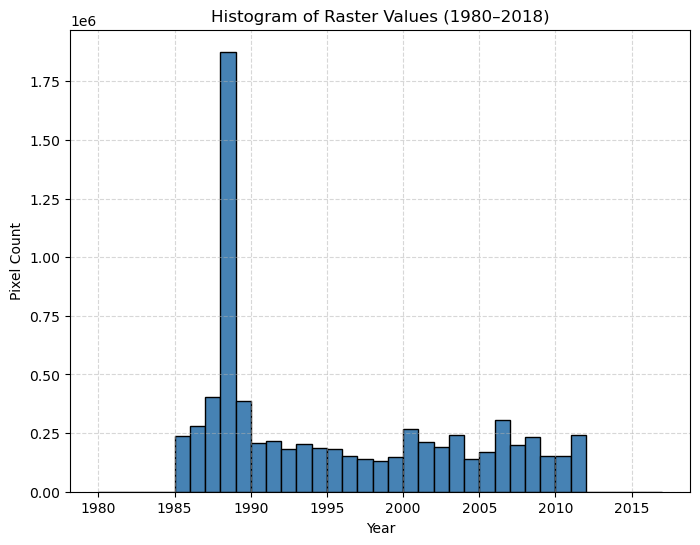

In [35]:
data_filtered = Trans_yr[(Trans_yr >= 1980) & (Trans_yr <= 2017)]
# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(data_filtered, bins=np.arange(1980, 2018, 1), color='steelblue', edgecolor='black')
plt.title("Histogram of Raster Values (1980–2018)")
plt.xlabel("Year")
plt.ylabel("Pixel Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [36]:
#skip if takes too long.
#with rasterio.open(Biomass_path) as src:
#    Biomass = src.read(1)  # read first band
#    extent = rasterio.plot.plotting_extent(src)
#    crs = src.crs

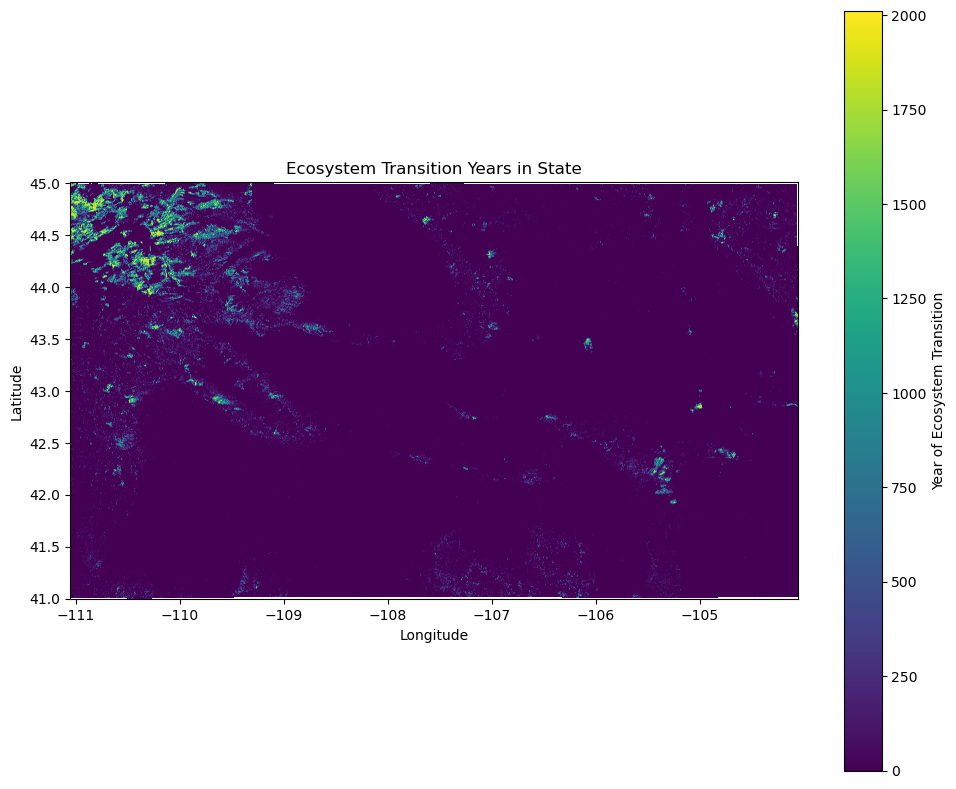

In [37]:
plt.figure(figsize=(10, 8))
img = plt.imshow(Trans_yr, cmap='viridis', extent=extent)
plt.colorbar(img, label="Year of Ecosystem Transition")
plt.title("Ecosystem Transition Years in State")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [38]:
# Plot smaller area
#bbox = (-108.5, 39.0, -107.5, 40.0)
#states = gpd.read_file(NC_RISCC_shp_path)

In [39]:
#with rasterio.open(Trans_yr_path) as src:
#    window = from_bounds(*bbox, transform=src.transform)
#    Trans_yr_small = src.read(1, window=window)
#    transform = src.window_transform(window)
#xmin = transform.c
#xmax = transform.c + transform.a * Trans_yr_small.shape[1]
#ymax = transform.f
#ymin = transform.f + transform.e * Trans_yr_small.shape[0]
#extent = (xmin, xmax, ymin, ymax)

#plt.figure(figsize=(8, 6))
#plt.imshow(Trans_yr_small, cmap='viridis', extent=extent)
#plt.colorbar(label='Year of Transition')
#plt.title('Zoomed-in Area of Ecosystem Transitions')
#plt.xlabel('Longitude')
#plt.ylabel('Latitude')
#plt.show()

In [40]:
#plt.figure(figsize=(10, 8))
#img = plt.imshow(Biomass, cmap=cmap, extent=extent)
#plt.colorbar(img, label="Biomass 2003")
#plt.title("Biomass NC Region 2003")
#plt.xlabel("Longitude")
#plt.ylabel("Latitude")
#plt.tight_layout()
#plt.show()

## Clip Data to State Shapefile

In [41]:
input_tif = Trans_yr_path
output_tif = output_tif_trans
states = gpd.read_file(NC_RISCC_shp_path)

# --- Filter to state ---
state_abbr = state_abbr
state_shape = states[states["STATE_ABBR"] == state_abbr]

# Check we got one feature
if state_shape.empty:
    raise ValueError(f"No features found for STATE_ABBR = '{state_abbr}'")

# --- Open the raster and clip ---
with rasterio.open(input_tif) as src:
    # Ensure CRS match
    if state_shape.crs != src.crs:
        state_shape = state_shape.to_crs(src.crs)

    # Convert geometry to GeoJSON-like dict
    geoms = [geom.__geo_interface__ for geom in state_shape.geometry]

    # Clip raster using the selected state's geometry
    data, transform = mask(src, geoms, crop=True)

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": data.shape[1],
        "width": data.shape[2],
        "transform": transform
    })

# --- Save the clipped raster ---
with rasterio.open(output_tif, "w", **meta) as dest:
    dest.write(data)

print(f"✅ Clipped raster saved to: {output_tif}")

✅ Clipped raster saved to: WY_trans.tif


In [42]:
input_tif = Biomass_path
output_tif = output_tif_bm
states = gpd.read_file(NC_RISCC_shp_path)

# --- Filter to state ---
state_abbr = state_abbr
state_shape = states[states["STATE_ABBR"] == state_abbr]

# Check we got one feature
if state_shape.empty:
    raise ValueError(f"No features found for STATE_ABBR = '{state_abbr}'")

# --- Open the raster and clip ---
with rasterio.open(input_tif) as src:
    # Ensure CRS match
    if state_shape.crs != src.crs:
        state_shape = state_shape.to_crs(src.crs)

    # Convert geometry to GeoJSON-like dict
    geoms = [geom.__geo_interface__ for geom in state_shape.geometry]

    # Clip raster using the selected state's geometry
    data, transform = mask(src, geoms, crop=True)

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": data.shape[1],
        "width": data.shape[2],
        "transform": transform
    })

# --- Save the clipped raster ---
with rasterio.open(output_tif, "w", **meta) as dest:
    dest.write(data)

print(f"✅ Clipped raster for {state_abbr} saved to: {output_tif}")

✅ Clipped raster for WY saved to: biomass_clip_WY.tif


## Resample state data to biomass pixels

In [43]:
trans = output_tif_trans
bm = output_tif_bm
output_tif = output_tif_resampled

In [44]:
with rasterio.open(bm) as src, rasterio.open(trans) as ref:
    # Prepare output metadata
    out_meta = src.meta.copy()
    out_meta.update({
        "crs": ref.crs,
        "transform": ref.transform,
        "width": ref.width,
        "height": ref.height
    })
    
    # Create empty array for all bands
    out_data = np.empty((src.count, ref.height, ref.width), dtype=src.dtypes[0])
    
    for i in range(1, src.count + 1):
        reproject(
            source=rasterio.band(src, i),
            destination=out_data[i - 1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref.transform,
            dst_crs=ref.crs,
            resampling=Resampling.bilinear  # use nearest if categorical
        )

    # Write output
    with rasterio.open(output_tif, "w", **out_meta) as dst:
        dst.write(out_data)


## Visualize Resampled Data

In [45]:
with rasterio.open(output_tif) as src:
    BM_clip_resample = src.read(1)  # read first band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs
with rasterio.open(bm) as src:
    bm_clip = src.read(2)  # read first band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs
with rasterio.open(trans) as src:
    trans_clip = src.read(1)  # read first band
    extent = rasterio.plot.plotting_extent(src)
    crs = src.crs

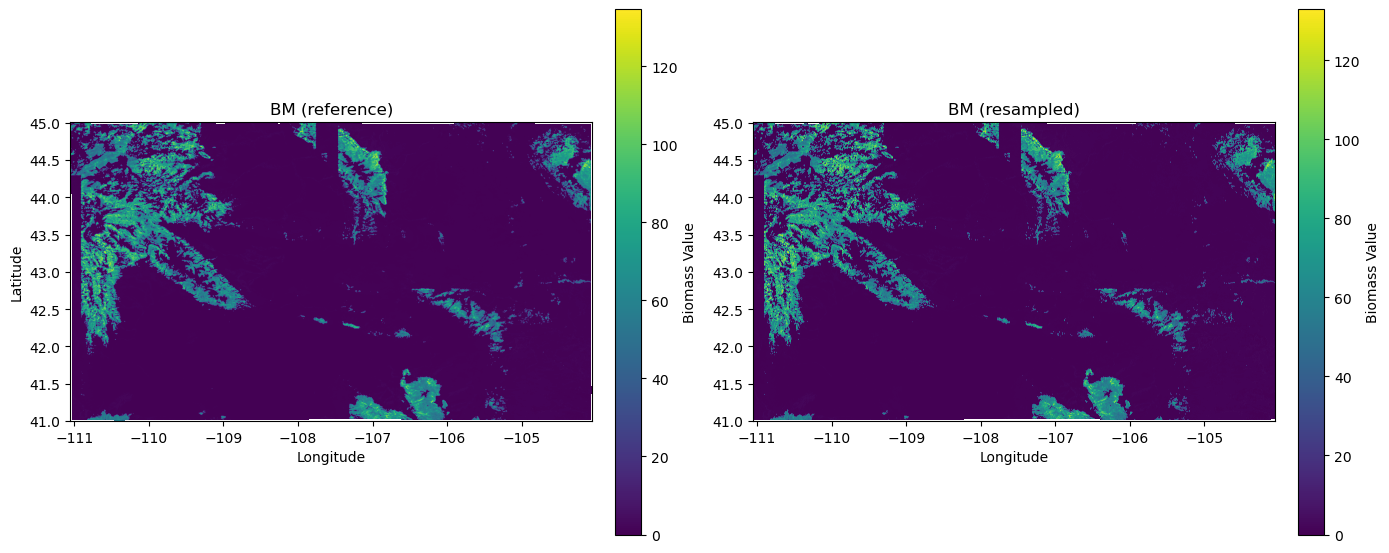

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

img1 = ax1.imshow(bm_clip, cmap='viridis', extent=extent)
ax1.set_title("BM (reference)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
fig.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04, label='Biomass Value')

img2 = ax2.imshow(BM_clip_resample, cmap='viridis', extent=extent)
ax2.set_title("BM (resampled)")
ax2.set_xlabel("Longitude")
fig.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04, label='Biomass Value')

plt.tight_layout()
plt.show()

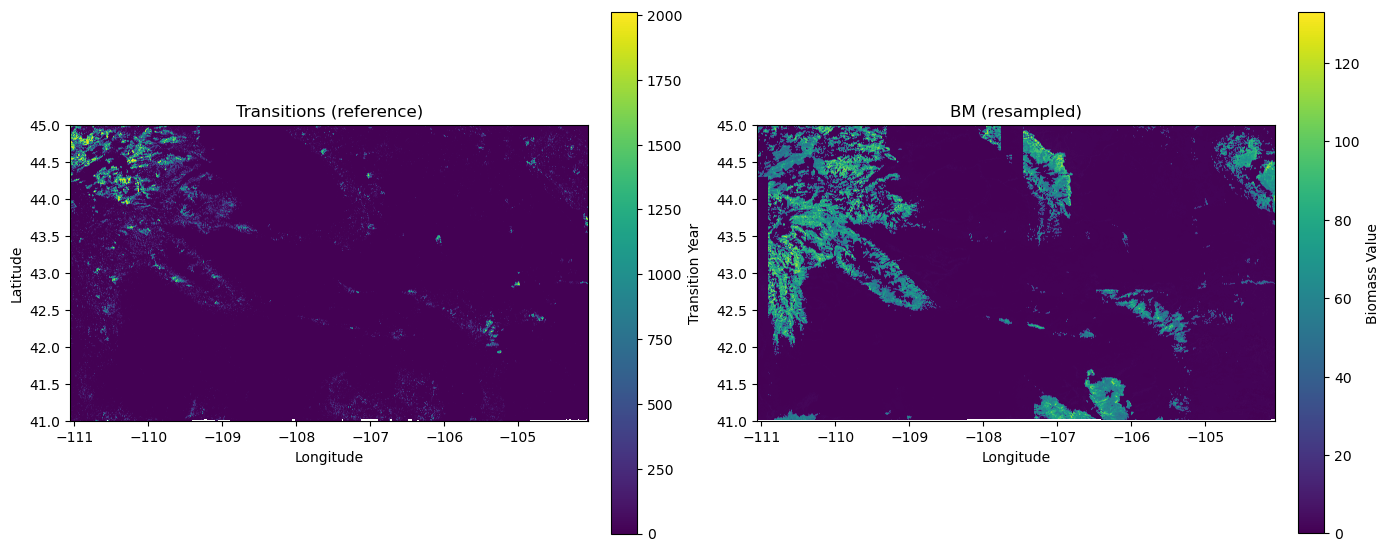

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

img1 = ax1.imshow(trans_clip, cmap='viridis', extent=extent)
ax1.set_title("Transitions (reference)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
fig.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04, label='Transition Year')

img2 = ax2.imshow(BM_clip_resample, cmap='viridis', extent=extent)
ax2.set_title("BM (resampled)")
ax2.set_xlabel("Longitude")
fig.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04, label='Biomass Value')

plt.tight_layout()
plt.show()